In [5]:
%load_ext autoreload
%autoreload 2


In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.append('../src')

from data_pipeline import load_all_raw_data
from data_analysis import (
    filter_data_until_date, temporal_split_data, 
    plot_user_analysis, plot_temporal_analysis, 
    plot_station_analysis, plot_activity_heatmap, 
    print_summary_statistics
)
from preprocess import (
    analyze_users_for_visualization, 
    analyze_trips_for_visualization
)
from weather_data import WeatherDataCollector


In [7]:

raw_data_dir = Path('../data/raw')
save_dir = Path('../data/raw/combined')

users_df, trips_df = load_all_raw_data(raw_data_dir, save_dir, verbose=True)

print(f"Datos cargados: {len(users_df):,} usuarios, {len(trips_df):,} viajes")


INICIANDO CARGA OPTIMIZADA DE DATOS RAW
Cargando datos de usuarios...
Cargando: usuarios_ecobici_2020.csv
   107,166 filas cargadas en 0.13s
Cargando: usuarios_ecobici_2021.csv
   81,577 filas cargadas en 0.06s
Cargando: usuarios_ecobici_2022.csv
   105,997 filas cargadas en 0.13s
Cargando: usuarios_ecobici_2023.csv
   136,066 filas cargadas en 0.15s
Cargando: usuarios_ecobici_2024.csv
   197,077 filas cargadas en 0.18s
Concatenando 5 archivos con 627,883 filas totales...
   Concatenacion completada en 0.08s
Total usuarios: 627,883 registros
Columnas usuarios: ['id_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta', 'hora_alta']

Cargando datos de viajes...
Cargando: trips_2020.csv
Found concatenated coordinates, separating...
   2,415,597 filas cargadas en 22.74s
Cargando: trips_2021.csv
Found concatenated coordinates, separating...
   2,860,091 filas cargadas en 31.02s
Cargando: trips_2022.csv
   2,922,805 filas cargadas en 21.98s
Cargando: trips_2023.csv
   2,622,331 filas car

In [8]:
print("🔍 ORIGINAL RAW DATA ANALYSIS (BEFORE PREPROCESSING)")
print("=" * 60)

print("Number of null values per column (ORIGINAL):")
nan_counts_original = trips_df.isnull().sum()
print(nan_counts_original)

print("\nPercentage of null values per column (ORIGINAL):")
nan_percentages_original = (trips_df.isnull().sum() / len(trips_df) * 100).round(2)
print(nan_percentages_original)

print("\nMin and max values per column:")
for col in trips_df.columns:
    try:
        min_val = trips_df[col].min()
        max_val = trips_df[col].max()
        print(f"\n{col}:")
        print(f"  Min: {min_val}")
        print(f"  Max: {max_val}")
    except:
        print(f"\n{col}: Cannot calculate min/max (likely non-numeric)")

print(f"\nOriginal dataset shape: {trips_df.shape}")
print(f"Original columns: {list(trips_df.columns)}")

key_cols = ['id_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario', 'duracion_recorrido', 'genero']


🔍 ORIGINAL RAW DATA ANALYSIS (BEFORE PREPROCESSING)
Number of null values per column (ORIGINAL):
id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino              43
nombre_estacion_destino          43
direccion_estacion_destino       43
long_estacion_destino            43
lat_estacion_destino             43
id_usuario                        0
modelo_bicicleta                  0
genero                        76061
dtype: int64

Percentage of null values per column (ORIGINAL):
id_recorrido                  0.00
duracion_recorrido            0.00
fecha_origen_recorrido        0.00
id_estacion_origen            0.00
nombre_estacion_origen        0.00
direccion_estacion_origen     0.00
long_estacion_orig

In [ ]:

users_filtered, trips_filtered = filter_data_until_date(
    users_df, trips_df, 
    max_date="2024-08-31",
    verbose=False
)


data_splits = temporal_split_data(
    users_filtered, trips_filtered,
    train_end_date="2023-06-30",  # Train until jun 2023
    val_end_date="2023-12-31",    # Val jul-dec 2023  
    test_end_date="2024-08-31",   # Test jan-aug 2024
    verbose=False
)


### Weather



In [29]:
weather_collector = WeatherDataCollector(cache_dir='../data/cache')

def load_and_summarize_weather_data(weather_collector: WeatherDataCollector, weather_file_path: str = "../data/raw/meteo/hourly_open_meteo.csv"):
    """
    load weather data and print summary statistics
    
    parameters:
        weather_collector: weather data collector
        weather_file_path: path to weather data file
    
    returns:
        weather_df: dataframe with weather data
        weather_summary: dictionary with weather statistics
    """
    # initialize collector and load data
    weather_df = weather_collector.load_weather_data(weather_file_path)
    
    # print basic info
    print(f"\nweather dataframe shape: {weather_df.shape}")
    print(f"weather columns: {list(weather_df.columns)}")
    print(f"date range: {weather_df['date'].min()} to {weather_df['date'].max()}")
    
    # get and print summary stats
    weather_summary = weather_collector.get_weather_summary(weather_df)
    print(f"\nweather summary:")
    print(f"total records: {weather_summary['total_records']:,}")
    print(f"temperature range: {weather_summary['temperature_stats']['min']:.1f}°C to {weather_summary['temperature_stats']['max']:.1f}°C")
    print(f"mean temperature: {weather_summary['temperature_stats']['mean']:.1f}°C")
    print(f"total precipitation: {weather_summary['precipitation_stats']['total_mm']:.1f}mm")
    print(f"rainy hours: {weather_summary['precipitation_stats']['rainy_hours']:,}")
    print(f"mean wind speed: {weather_summary['wind_stats']['mean_speed_10m']:.1f} km/h")
    
    return weather_df, weather_summary

# load and summarize weather data
weather_df, weather_summary = load_and_summarize_weather_data()



weather dataframe shape: (43848, 32)
weather columns: ['date', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit', 'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm', 'sunshine_duration', 'is_day', 'direct_radiation']
date range: 2020-01-01 03:00:00+00:00 to 2025-01-01 02:00:00+00:00

weather summary:
total records: 43,848
temperature range: -1.4°C to 38.9°C
mean temperature: 17.5°C
total precipitation: 4470.5mm
rainy hours: 4,079
mean wind speed: 15.9 km/h


In [30]:

print(f"\nfirst 5 rows of weather data:")
weather_df.head(5)



first 5 rows of weather data:


,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,weather_code,pressure_msl,surface_pressure,...,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,sunshine_duration,is_day,direct_radiation
0,2020-01-01 03:00:00+00:00,21.311000,87.557816,19.161001,22.377872,0.0,0.0,1.0,1010.7,1008.47485,...,24.361,22.961,18.861,0.468,0.484,0.387,0.455,0.0,0.0,0.0
1,2020-01-01 04:00:00+00:00,20.661001,90.842300,19.111000,21.789688,0.0,0.0,1.0,1010.9,1008.66974,...,24.261,22.961,18.861,0.468,0.483,0.388,0.455,0.0,0.0,0.0
2,2020-01-01 05:00:00+00:00,20.211000,92.242134,18.911001,21.202090,0.0,0.0,0.0,1011.1,1008.86580,...,24.111,22.961,18.861,0.468,0.483,0.388,0.455,0.0,0.0,0.0
3,2020-01-01 06:00:00+00:00,19.961000,92.516730,18.711000,20.706026,0.0,0.0,3.0,1011.0,1008.76410,...,24.011,22.961,18.861,0.468,0.482,0.388,0.455,0.0,0.0,0.0
4,2020-01-01 07:00:00+00:00,19.761000,91.640465,18.361000,20.033457,0.0,0.0,3.0,1011.2,1008.96210,...,23.861,22.961,18.861,0.468,0.482,0.388,0.455,0.0,0.0,0.0


In [31]:

# create enhanced weather features for better analysis
weather_with_features = weather_collector.create_weather_features(weather_df)
print(f"created additional weather features")
print(f"enhanced weather columns: {len(weather_with_features.columns)} total")

# weather_with_features.head()


created additional weather features
enhanced weather columns: 45 total


In [32]:

# match weather to training trips (taking a sample for demonstration)
print("\nmatching weather to trip data...")

# match weather conditions to trips
trips_with_weather = weather_collector.match_weather_to_trips(
    trips_filtered, 
    # weather_with_features,
    weather_df,
    date_column='fecha_origen_recorrido'
)

print(f"\ntrips with weather data shape: {trips_with_weather.shape}")
print(f"new columns added: {len(trips_with_weather.columns) - len(trips_filtered.columns)}")




matching weather to trip data...
matching weather conditions to trips...
finding weather conditions for each trip...
matched weather data for 12,976,053 out of 12,976,053 trips (100.0%)

trips with weather data shape: (12976053, 48)
new columns added: 31

weather features added to trips:
   1. weather_temperature_2m
   2. weather_relative_humidity_2m
   3. weather_dew_point_2m
   4. weather_apparent_temperature
   5. weather_precipitation
   6. weather_rain
   7. weather_weather_code
   8. weather_pressure_msl
   9. weather_surface_pressure
  10. weather_cloud_cover
  ... and 21 more weather features

sample of trips with weather conditions:


In [34]:
def analyze_weather_impact(trips_df):
    """analyze impact of weather conditions on bike usage and trip duration"""
    results = {}
    
    # temperature analysis
    if 'weather_temperature_2m' in trips_df.columns:
        temp_ranges = pd.cut(trips_df['weather_temperature_2m'],
                           bins=[-float('inf'), 10, 15, 20, 25, 30, float('inf')],
                           labels=['<10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C'])
        results['temperature'] = {
            'usage': temp_ranges.value_counts().sort_index(),
            'duration': trips_df.groupby(temp_ranges)['duracion_recorrido'].mean() if 'duracion_recorrido' in trips_df.columns else None
        }
    
    # rain analysis
    if 'weather_is_raining' in trips_df.columns:
        results['rain'] = {
            'usage': trips_df['weather_is_raining'].value_counts(),
            'duration': trips_df.groupby('weather_is_raining')['duracion_recorrido'].mean() if 'duracion_recorrido' in trips_df.columns else None
        }
    
    # wind analysis
    if 'weather_wind_speed_10m' in trips_df.columns:
        wind_ranges = pd.cut(trips_df['weather_wind_speed_10m'],
                           bins=[0, 10, 20, 30, float('inf')],
                           labels=['calm (0-10)', 'light (10-20)', 'moderate (20-30)', 'strong (>30)'])
        results['wind'] = {
            'usage': wind_ranges.value_counts().sort_index()
        }
    
    return results

def print_weather_analysis(results, total_trips):
    """print formatted weather analysis results"""
    # temperature impact
    if 'temperature' in results:
        print("temperature impact on bike usage:")
        for temp_range, count in results['temperature']['usage'].items():
            percentage = count / total_trips * 100
            print(f"  {temp_range}: {count:,} trips ({percentage:.1f}%)")
        
        if results['temperature']['duration'] is not None:
            print("\naverage trip duration by temperature:")
            for temp_range, avg_duration in results['temperature']['duration'].items():
                print(f"  {temp_range}: {avg_duration:.0f} seconds")
    
    # rain impact
    if 'rain' in results:
        print("\nrain impact on bike usage:")
        for is_raining, count in results['rain']['usage'].items():
            condition = "rainy" if is_raining else "dry"
            percentage = count / total_trips * 100
            print(f"  {condition} conditions: {count:,} trips ({percentage:.1f}%)")
        
        if results['rain']['duration'] is not None:
            print("\naverage trip duration by rain conditions:")
            for is_raining, avg_duration in results['rain']['duration'].items():
                condition = "rainy" if is_raining else "dry"
                print(f"  {condition}: {avg_duration:.0f} seconds")
    
    # wind impact
    if 'wind' in results:
        print("\nwind impact on bike usage:")
        for wind_range, count in results['wind']['usage'].items():
            percentage = count / total_trips * 100
            print(f"  {wind_range} km/h: {count:,} trips ({percentage:.1f}%)")

# analyze weather impact
weather_results = analyze_weather_impact(trips_with_weather)
print_weather_analysis(weather_results, len(trips_with_weather))


temperature impact on bike usage:
  <10°C: 1,070,339 trips (8.2%)
  10-15°C: 2,618,189 trips (20.2%)
  15-20°C: 3,296,999 trips (25.4%)
  20-25°C: 3,611,460 trips (27.8%)
  25-30°C: 2,015,765 trips (15.5%)
  >30°C: 363,301 trips (2.8%)

wind impact on bike usage:
  calm (0-10) km/h: 2,446,094 trips (18.9%)
  light (10-20) km/h: 6,969,231 trips (53.7%)
  moderate (20-30) km/h: 3,145,176 trips (24.2%)
  strong (>30) km/h: 415,359 trips (3.2%)

average trip duration by weather:
  by temperature:
    <10°C: 1176 seconds
    10-15°C: 1255 seconds
    15-20°C: 1309 seconds
    20-25°C: 1475 seconds
    25-30°C: 1594 seconds
    >30°C: 1595 seconds


In [35]:

users_train = data_splits['users_train']
users_val = data_splits['users_val'] 
users_test = data_splits['users_test']

trips_train = data_splits['trips_train']
trips_val = data_splits['trips_val']
trips_test = data_splits['trips_test']


print(f"Users: Train={len(users_train):,}, Val={len(users_val):,}, Test={len(users_test):,}")
print(f"Trips: Train={len(trips_train):,}, Val={len(trips_val):,}, Test={len(trips_test):,}")
print(f"Final columns: {list(trips_train.columns)}")


Users: Train=346,517, Val=84,289, Test=115,204
Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103
Final columns: ['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']



Estadísticas de entrenamiento:
Usuarios en train: (346517, 5)
Viajes en train: (9505149, 17)

Generando análisis de usuarios...


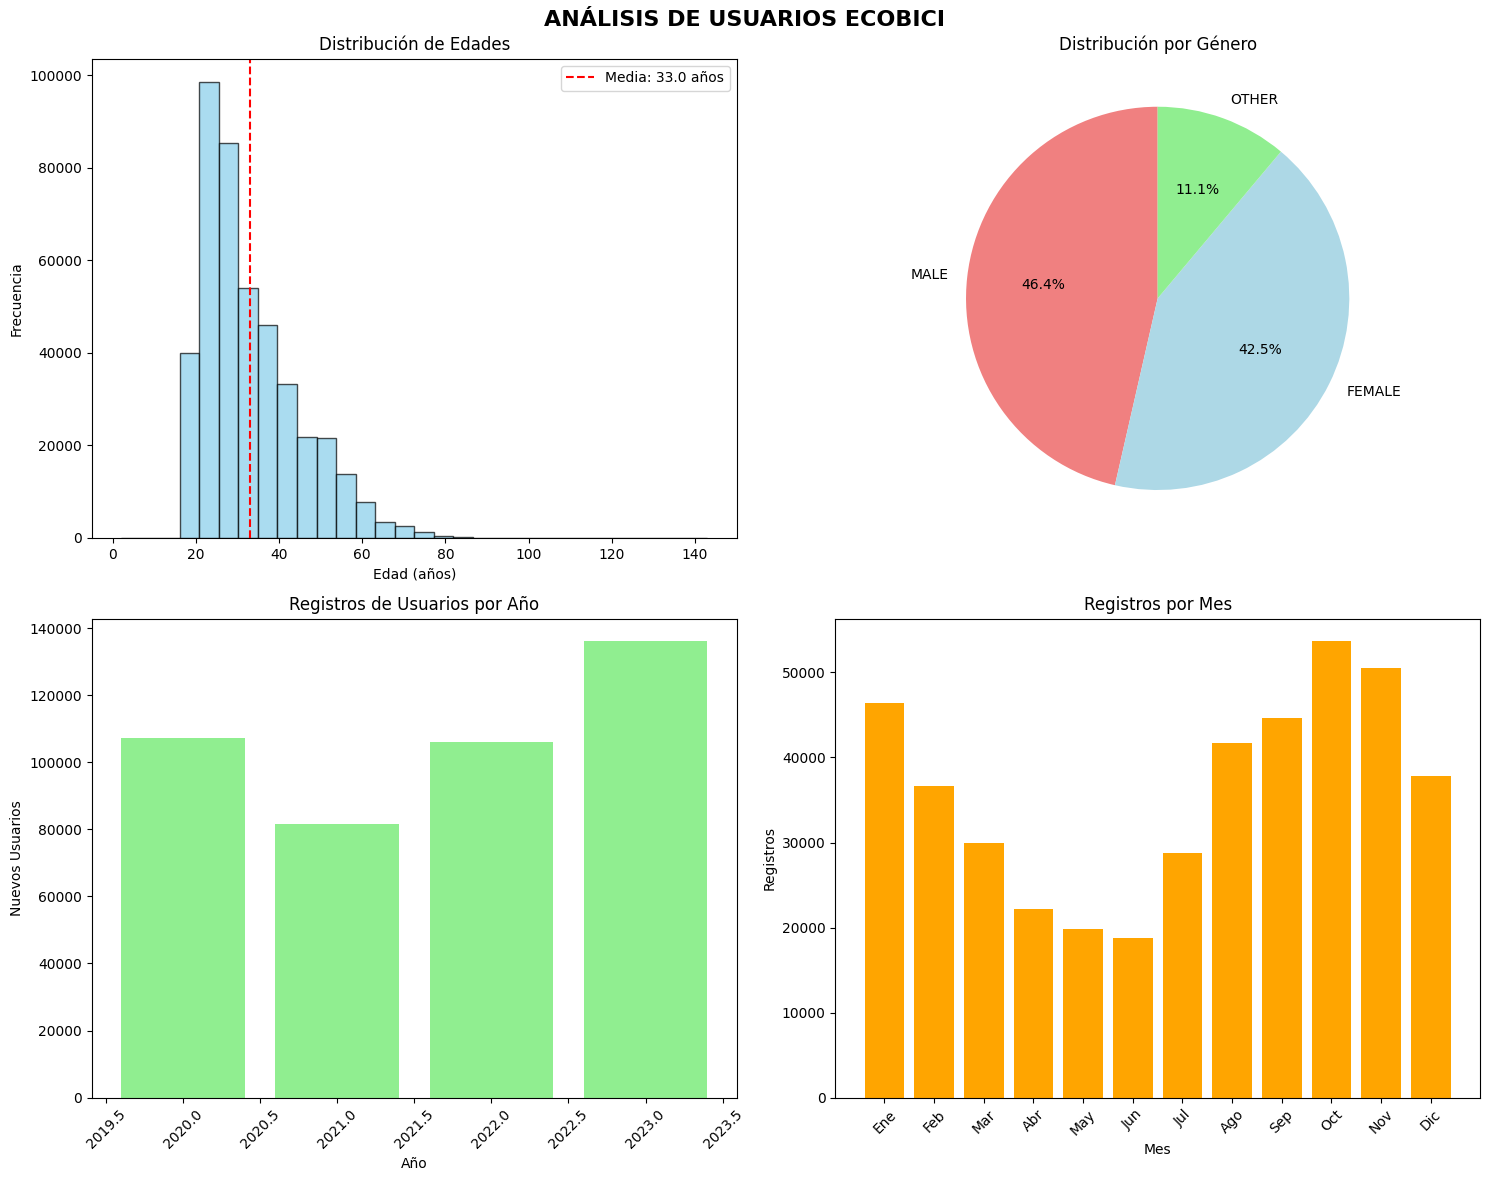

Generando análisis temporal...


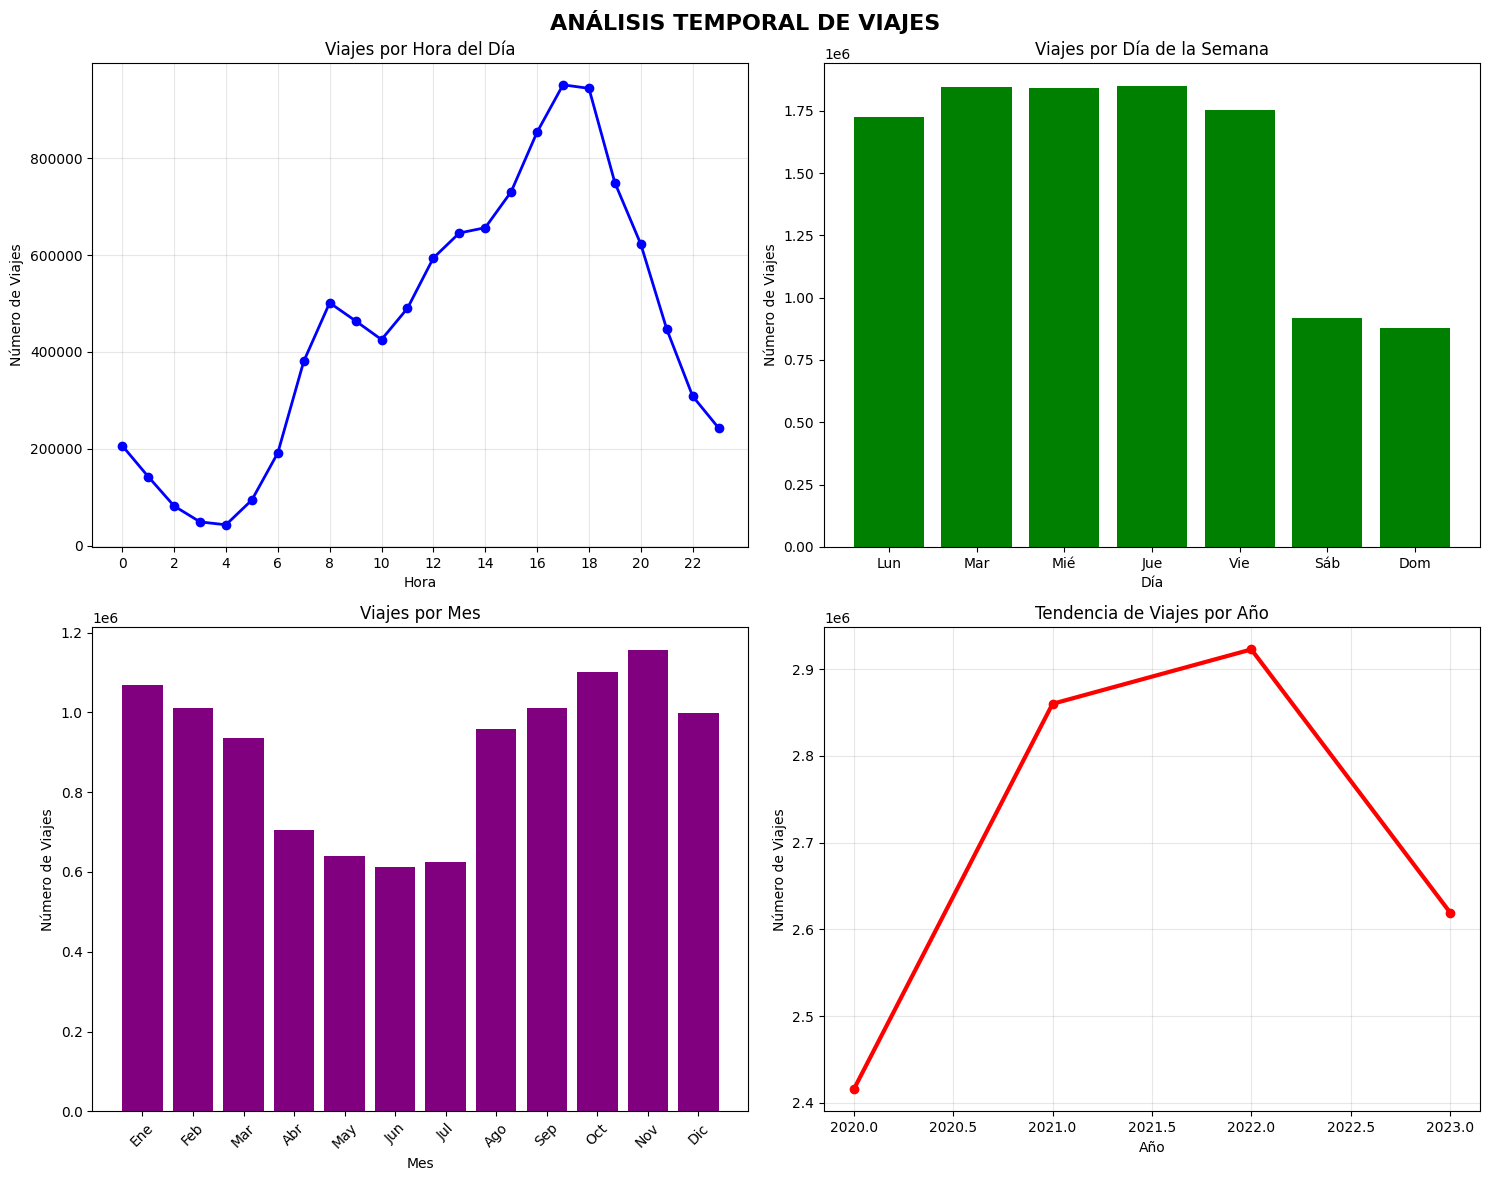

Generando análisis de estaciones...


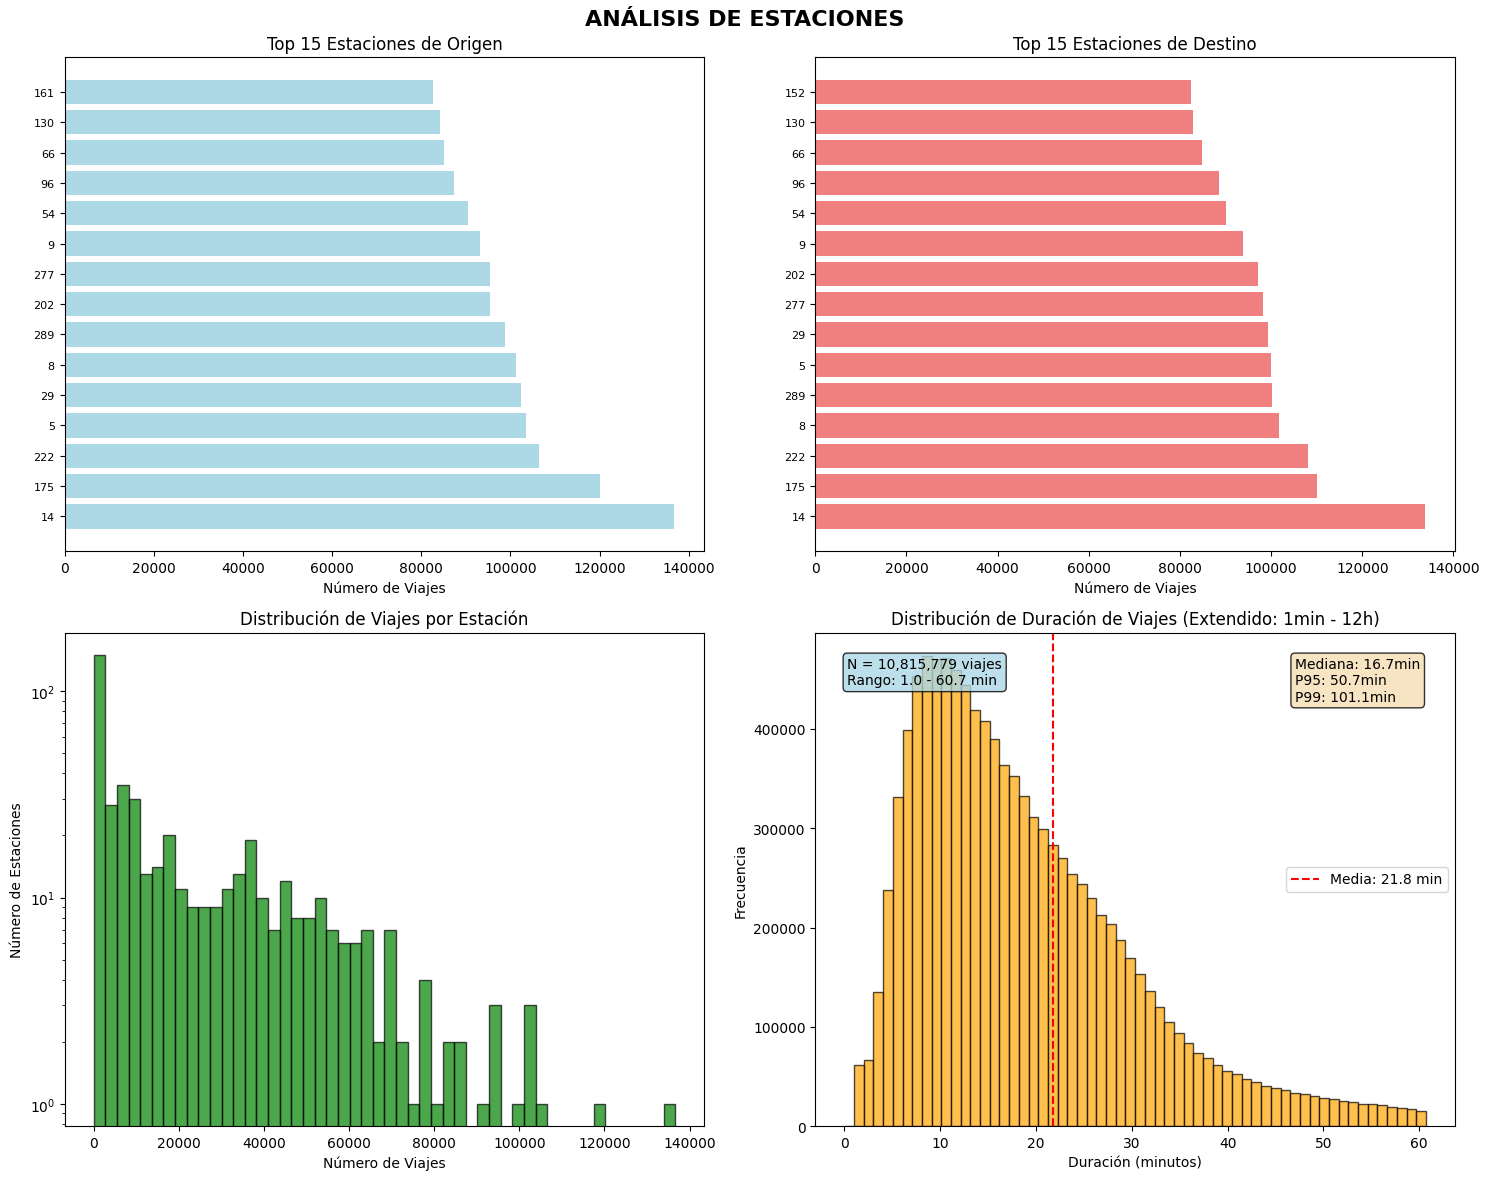

Generando heatmap de actividad...


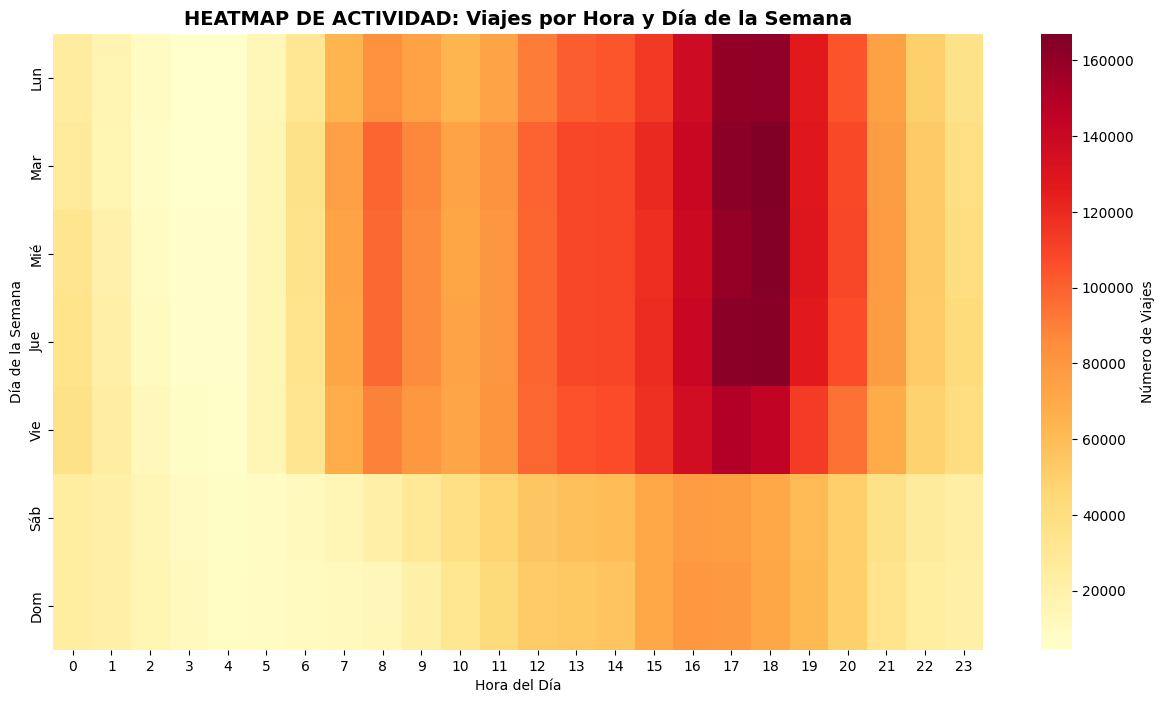


ESTADÍSTICAS RESUMEN
USUARIOS:
   • Total usuarios: 546,010
   • Edad promedio: 33.0 años
   • Distribución de género:
     - MALE: 199,987 (36.6%)
     - FEMALE: 182,907 (33.5%)
     - OTHER: 47,910 (8.8%)

VIAJES:
   • Total viajes: 12,976,053
   • Período: 2020-01-01 00:00:08 - 2023-12-30 23:59:32
   • Promedio viajes/día: 8,888
   • Estaciones únicas (origen): 484
   • Estaciones únicas (destino): 15
   • Duración promedio: 21.8 minutos


In [36]:
# combine train and validation data first, then analyze
users_combined = pd.concat([users_train, users_val], axis=0)
trips_combined = pd.concat([trips_train, trips_val], axis=0)

# analyze combined data
processed_users = analyze_users_for_visualization(users_combined)
processed_trips = analyze_trips_for_visualization(trips_combined)

# print training statistics
print(f"\nEstadísticas de entrenamiento:")
print(f"Usuarios en train: {users_train.shape}")
print(f"Viajes en train: {trips_train.shape}")

# generate analysis plots
print("\nGenerando análisis de usuarios...")
plot_user_analysis(processed_users, save_plots=False, output_dir=None)

print("Generando análisis temporal...")
plot_temporal_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando análisis de estaciones...")
plot_station_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando heatmap de actividad...")
plot_activity_heatmap(processed_trips, save_plots=False, output_dir=None)

# print summary statistics
print_summary_statistics(users_combined, processed_users, trips_combined, processed_trips)


In [18]:
len(trips_df['id_estacion_origen'].unique())
trips_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,7210548,1582,2020-01-24 21:54:39,27,027 - Montevideo,Cordoba Av. & Montevideo,-58.390089,-34.599068,2020-01-24 22:21:01,3,003 - ADUANA,Moreno & Av Paseo Colon,-58.368260,-34.611032,192009,ICONIC,FEMALE
1,7199093,204,2020-01-24 07:04:19,151,151 - AIME PAINÉ,"Villaflor, Azucena & Paine, Aime",-58.361285,-34.611815,2020-01-24 07:07:43,3,003 - ADUANA,Moreno & Av Paseo Colon,-58.368260,-34.611032,36380,ICONIC,MALE
2,7196805,1790,2020-01-24 00:15:17,111,111 - MACACHA GUEMES,Machaca Guemes 350,-58.364686,-34.605488,2020-01-24 00:45:07,3,003 - ADUANA,Moreno & Av Paseo Colon,-58.368260,-34.611032,460080,ICONIC,MALE
3,7203598,10688,2020-01-24 12:38:16,285,400 - Reserva Ecologica,"Achaval Rodriguez, T., Dr. Av. 1520",-58.356175,-34.617212,2020-01-24 15:36:24,4,004 - Plaza Roma,Lavalle & Bouchard,-58.368781,-34.601822,3857,ICONIC,MALE
4,7200335,673,2020-01-24 08:31:01,171,171 - Pasteur,519 Pasteur,-58.399755,-34.603281,2020-01-24 08:42:14,7,007 - OBELISCO,CARLOS PELEGRINI 215,-58.381098,-34.606498,391034,ICONIC,FEMALE
